# Assigment 6: Multiple Linear Regression
##### Author: Md Ashhar Farooqui
##### Date: 18-07-2025

Import pandas, numpy, matplotlib, seaborn, and scikit-learn libraries required for data analysis, visualization, and modeling.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Load and Inspect the Dataset

Load the Toyota Corolla dataset, display the first few rows, and check for missing values and data types.

In [2]:
# Load the dataset
df = pd.read_csv('ToyotaCorolla - MLR.csv', encoding='latin1')

# Display the first 5 rows
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
# Check for missing values and data types
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

# Exploratory Data Analysis (EDA)

In [4]:
# Summary statistics
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


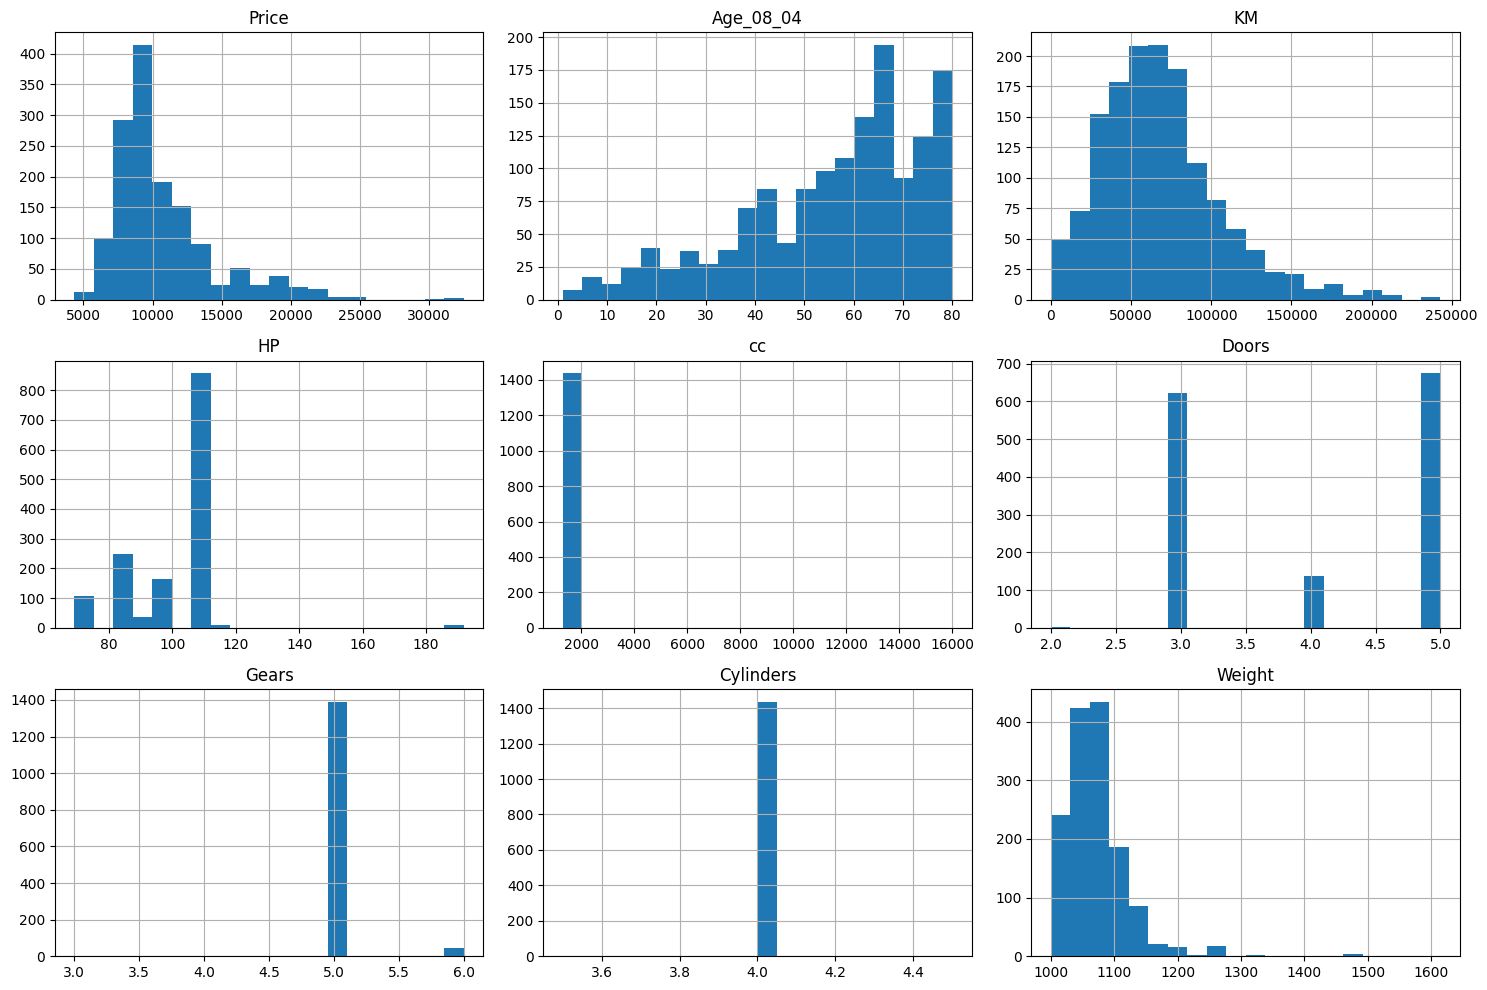

In [6]:
# Visualize distributions of numerical features
num_cols = ['Price', 'Age_08_04', 'KM', 'HP', 'cc', 'Doors', 'Gears', 'Cylinders', 'Weight']
df[num_cols].hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

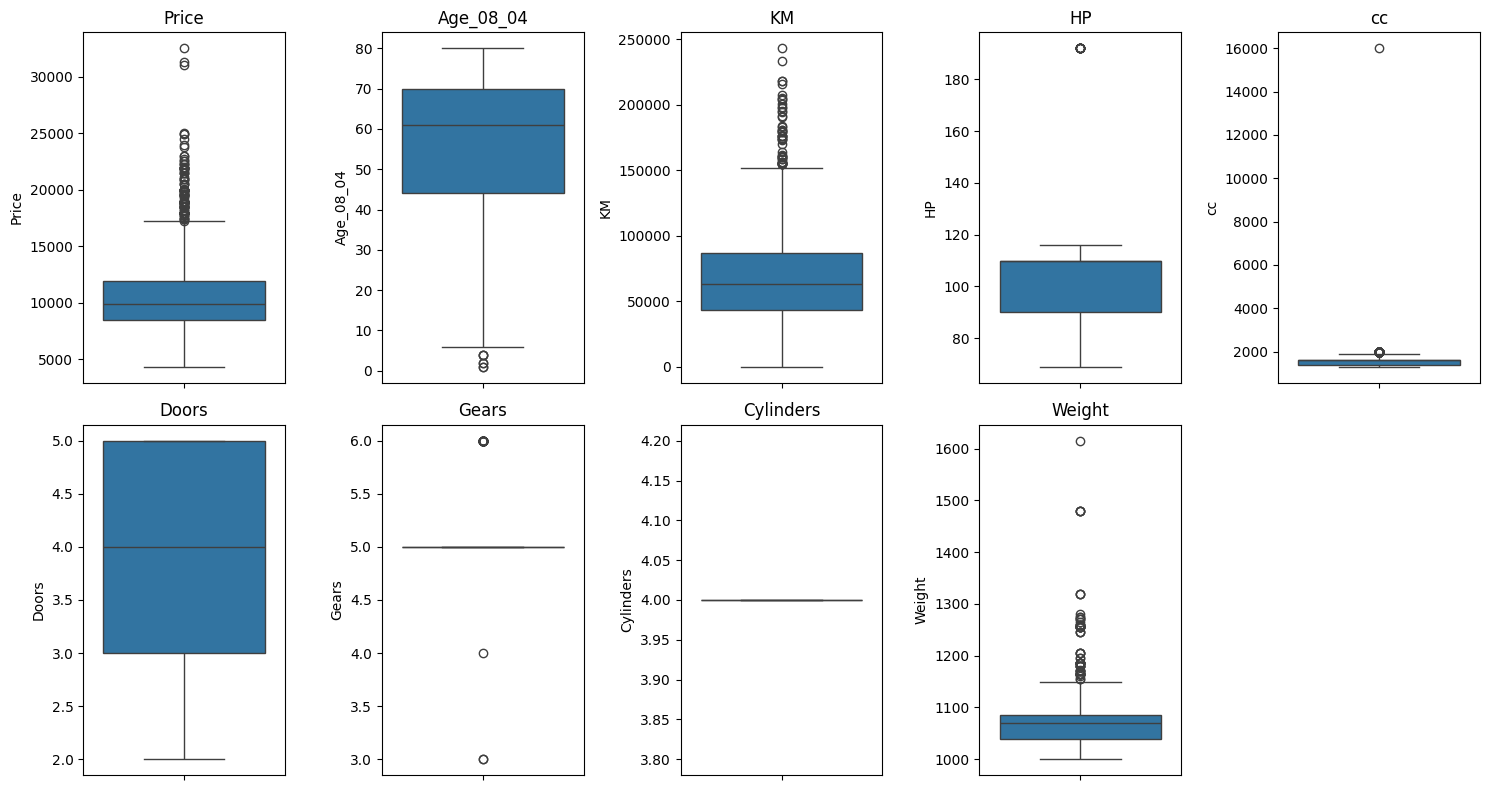

In [7]:
# Boxplots for outlier detection
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 5, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

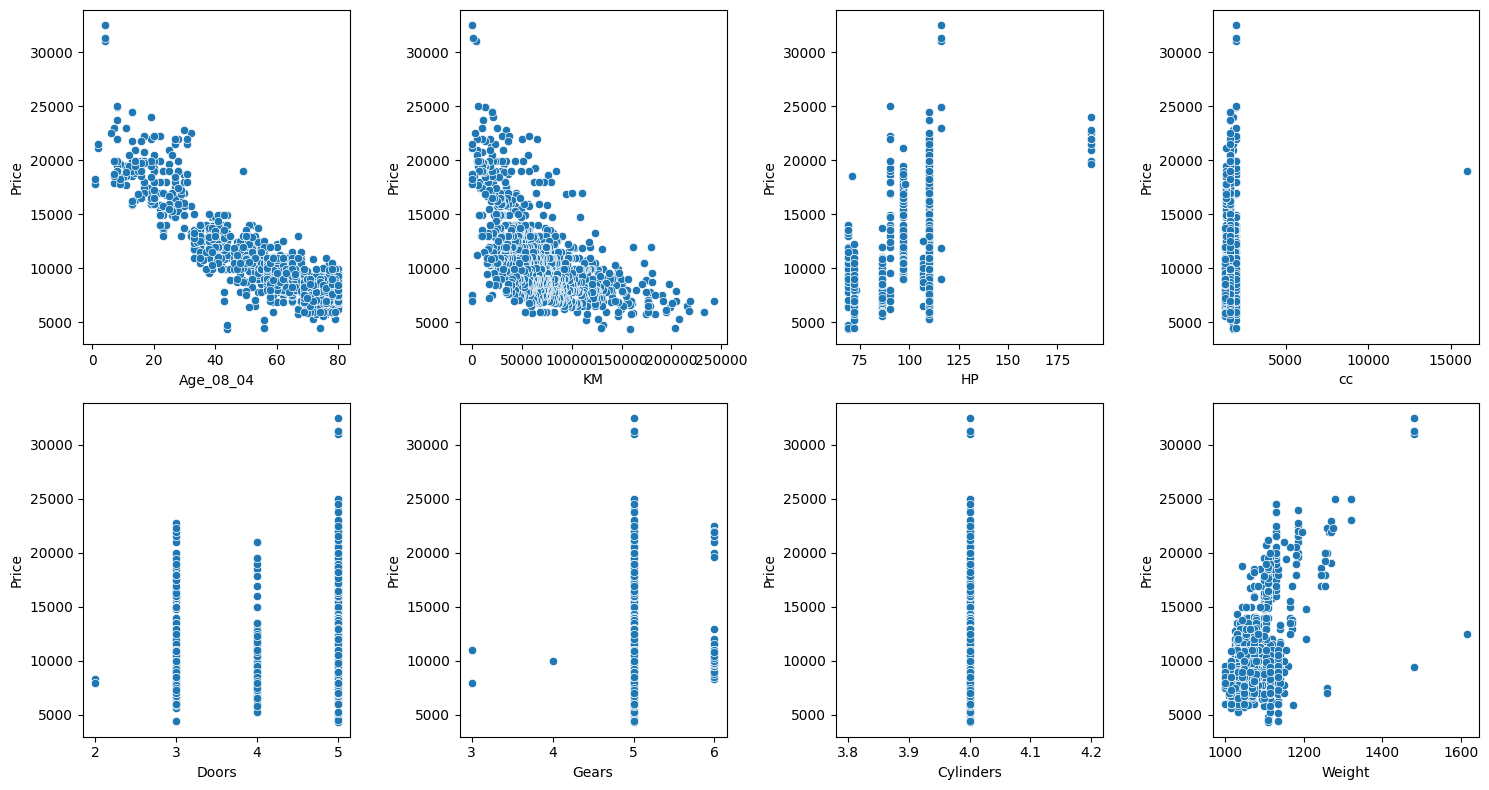

In [8]:
# Scatterplots: Relationship with Price
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols[1:]):  # Exclude 'Price' itself
    plt.subplot(2, 4, i+1)
    sns.scatterplot(x=df[col], y=df['Price'])
    plt.xlabel(col)
    plt.ylabel('Price')
plt.tight_layout()
plt.show()

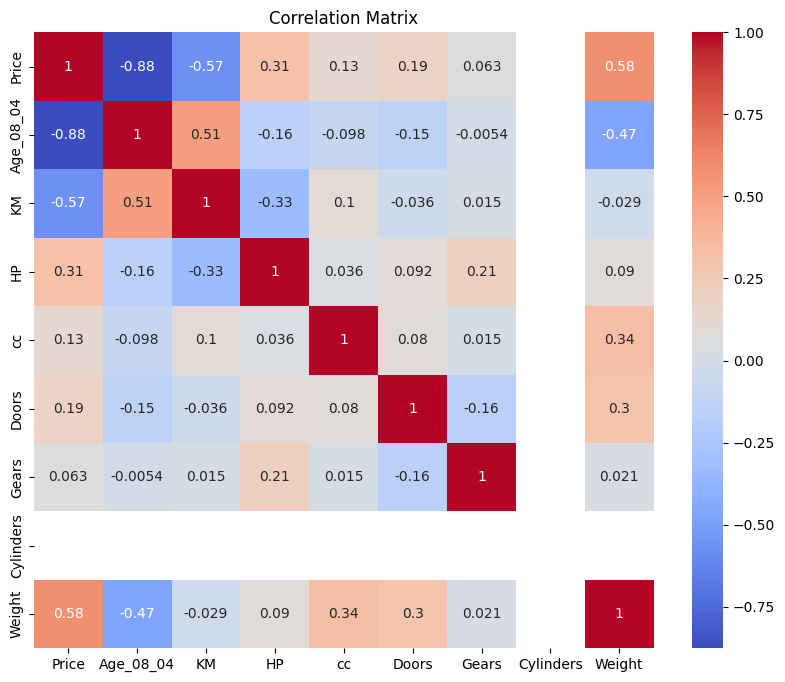

In [9]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Data Preprocessing

Handle missing values, encode categorical variables (e.g., FuelType, Doors), and scale/normalize features as needed for regression analysis.

In [11]:
# Handle missing values (if any)
df = df.dropna()

# Encode categorical variables
categorical_cols = ['Fuel_Type', 'Doors']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Feature scaling
scaler = StandardScaler()
feature_cols = [col for col in df.columns if col not in ['Price', 'Model', 'Id']]
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# Train-Test Split

Split the dataset into training and testing sets (e.g., 80% training, 20% testing) using scikit-learn's train_test_split.

In [12]:
# Define features and target
X = df[feature_cols]
y = df['Price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build Multiple Linear Regression Models

Build at least three different multiple linear regression models using different combinations of features or preprocessing techniques.

In [13]:
# Model 1: All features
lr1 = LinearRegression()
lr1.fit(X_train, y_train)
y_pred1 = lr1.predict(X_test)

# Model 2: Only numerical features
num_feature_cols = [col for col in feature_cols if df[col].dtype != 'uint8']
lr2 = LinearRegression()
lr2.fit(X_train[num_feature_cols], y_train)
y_pred2 = lr2.predict(X_test[num_feature_cols])

# Model 3: Exclude highly correlated features (e.g., drop 'Weight' if highly correlated with 'Price')
corr_matrix = df.corr()
high_corr = corr_matrix['Price'].abs().sort_values(ascending=False)
drop_cols = ['Weight'] if 'Weight' in high_corr.index and high_corr['Weight'] > 0.8 else []
selected_cols = [col for col in feature_cols if col not in drop_cols]
lr3 = LinearRegression()
lr3.fit(X_train[selected_cols], y_train)
y_pred3 = lr3.predict(X_test[selected_cols])

# Interpret Model Coefficients

Interpret the coefficients of the regression models to understand the impact of each feature on the predicted price.

In [14]:
# Coefficients for Model 1
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr1.coef_})
coef_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
7,Weight,1.424056e+03
9,Fuel_Type_Petrol,4.629548e+02
2,HP,1.768812e+02
6,Gears,1.115378e+02
3,Automatic,1.741399e+01
5,Cylinders,1.136868e-13
4,cc,-1.343582e+01
8,Fuel_Type_Diesel,-5.674492e+01
11,Doors_4,-6.815304e+01
10,Doors_3,-2.639391e+02


# Model Evaluation

Evaluate the performance of the models on the test set using metrics such as R-squared, RMSE, and MAE. Compare the results of different models.

In [15]:
def evaluate_model(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{model_name} - R2: {r2:.3f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}")

evaluate_model(y_test, y_pred1, "Model 1 (All features)")
evaluate_model(y_test, y_pred2, "Model 2 (Numerical features)")
evaluate_model(y_test, y_pred3, "Model 3 (Reduced features)")

Model 1 (All features) - R2: 0.833, RMSE: 1494.11, MAE: 978.20
Model 2 (Numerical features) - R2: 0.833, RMSE: 1494.11, MAE: 978.20
Model 3 (Reduced features) - R2: 0.833, RMSE: 1494.11, MAE: 978.20


# Apply Lasso and Ridge Regression

Apply Lasso and Ridge regression to the data, tune hyperparameters, and compare their performance with the standard linear regression models.

In [16]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
evaluate_model(y_test, y_pred_ridge, "Ridge Regression")

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
evaluate_model(y_test, y_pred_lasso, "Lasso Regression")

Ridge Regression - R2: 0.833, RMSE: 1493.04, MAE: 978.25
Lasso Regression - R2: 0.833, RMSE: 1493.97, MAE: 978.21


In [17]:
# Hyperparameter tuning for Ridge and Lasso (optional)
from sklearn.model_selection import GridSearchCV

# Ridge
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train)
print("Best Ridge alpha:", ridge_grid.best_params_)

# Lasso
lasso_params = {'alpha': [0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(Lasso(), lasso_params, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train, y_train)
print("Best Lasso alpha:", lasso_grid.best_params_)

Best Ridge alpha: {'alpha': 100}


c:\py-3.13.3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.465e+06, tolerance: 1.213e+06
  model = cd_fast.enet_coordinate_descent(
c:\py-3.13.3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.659e+07, tolerance: 1.145e+06
  model = cd_fast.enet_coordinate_descent(
c:\py-3.13.3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.805e+06, tolerance: 1.225e+06
  model = cd_fast.enet_

Best Lasso alpha: {'alpha': 10}


# Interview Questions and Explanations

## 1. What is the difference between normalization and standardization? When should each be used?

**Normalization** rescales the values into a range of [0, 1]. It is useful when you want to bound your features and when the distribution is not Gaussian.

**Standardization** transforms the data to have a mean of 0 and a standard deviation of 1. It is preferred when the data follows a Gaussian distribution or when algorithms assume standardized data (e.g., linear regression, logistic regression).

## 2. What techniques can be used to address multicollinearity in multiple linear regression?

- **Remove highly correlated features**: Drop one of the variables that are highly correlated.
- **Principal Component Analysis (PCA)**: Transform correlated features into a set of linearly uncorrelated components.
- **Regularization**: Use Ridge or Lasso regression, which can reduce the impact of multicollinearity by penalizing large coefficients.
- **Variance Inflation Factor (VIF)**: Calculate VIF for each feature and remove features with high VIF values.